# Customer & Product Behavioral Analysis

The **objective** of this notebook is to analyze customer purchasing
behavior and product engagement at the customer level.

The analysis focuses on:
- Understanding the size and characteristics of the customer base
- Comparing one-time and repeat customers
- Analyzing customer revenue, order frequency, and average order value
- Examining the number of unique products purchased by each customer
- Analyzing the time between consecutive customer orders
- Identifying behavioral patterns that may be relevant to customer
  retention and churn analysis

The analysis will produce a customer-level feature table that will
serve as the foundation for the subsequent RFM segmentation and
customer retention/churn analysis.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

In [5]:
# Import the data
PROJECT_DIR = Path.cwd().parent
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

sales_file = PROCESSED_DIR / "retail_sales_cleaned.csv"
customer_file = PROCESSED_DIR / "retail_customer_cleaned.csv"

sales_df = pd.read_csv(sales_file, parse_dates=["InvoiceDate"])
customer_df = pd.read_csv(customer_file, parse_dates=["InvoiceDate"])

print(f"Sales Dataset loaded: {sales_df.shape}")
print(f"Customers Dataset loaded: {customer_df.shape}")

C:\Users\tanya\AppData\Local\Temp\ipykernel_12464\4281330230.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  sales_df = pd.read_csv(sales_file, parse_dates=["InvoiceDate"])


Sales Dataset loaded: (524878, 10)
Customers Dataset loaded: (392692, 10)


In [7]:
print("Total transaction rows:", len(sales_df))
print("Rows with CustomerID:", len(customer_df))

Total transaction rows: 524878
Rows with CustomerID: 392692


In [8]:
# How many identifiable customers do we have?
total_customers = customer_df["CustomerID"].nunique()
print(f"Total identifiable customers : {total_customers:,}")

Total identifiable customers: 4,338


In [9]:
customer_summary = (
    customer_df
    .groupby("CustomerID")
    .agg(
        Revenue=("Sales", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum"),
        Unique_Products=("StockCode", "nunique"),
        First_Purchase=("InvoiceDate", "min"),
        Last_Purchase=("InvoiceDate", "max")
    )
)
customer_summary.head()

,Revenue,Orders,Units,Unique_Products,First_Purchase,Last_Purchase
CustomerID,,,,,,
12346.0,77183.60,1,74215,1,2011-01-18 10:01:00,2011-01-18 10:01:00
12347.0,4310.00,7,2458,103,2010-12-07 14:57:00,2011-12-07 15:52:00
12348.0,1797.24,4,2341,22,2010-12-16 19:09:00,2011-09-25 13:13:00
12349.0,1757.55,1,631,73,2011-11-21 09:51:00,2011-11-21 09:51:00
12350.0,334.40,1,197,17,2011-02-02 16:01:00,2011-02-02 16:01:00


In [11]:
# Calculate AOV
customer_summary["AOV"] = customer_summary["Revenue"] / customer_summary["Orders"]
customer_summary.head().round(2)

,Revenue,Orders,Units,Unique_Products,First_Purchase,Last_Purchase,AOV
CustomerID,,,,,,,
12346.0,77183.60,1,74215,1,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.60
12347.0,4310.00,7,2458,103,2010-12-07 14:57:00,2011-12-07 15:52:00,615.71
12348.0,1797.24,4,2341,22,2010-12-16 19:09:00,2011-09-25 13:13:00,449.31
12349.0,1757.55,1,631,73,2011-11-21 09:51:00,2011-11-21 09:51:00,1757.55
12350.0,334.40,1,197,17,2011-02-02 16:01:00,2011-02-02 16:01:00,334.40


In [12]:
# Calculate purchase span
customer_summary["Purchase_Span_Days"] = (
    customer_summary["Last_Purchase"]
    - customer_summary["First_Purchase"]
).dt.days

customer_summary["Purchase_Span_Days"].describe()

count    4338.000000
mean      130.448594
std       132.039554
min         0.000000
25%         0.000000
50%        92.500000
75%       251.750000
max       373.000000
Name: Purchase_Span_Days, dtype: float64

In [14]:
# One-time vs repeat customers
customer_summary["Customer_Type"] = np.where(
    customer_summary["Orders"] == 1,
    "One-Time",
    "Repeat"
)

# What proportion of customers return?
customer_type_share = (
    customer_summary["Customer_Type"]
    .value_counts(normalize=True)   # normalize converts counts into proportions
    .mul(100)
    .round(2)
)
customer_type_share

Customer_Type
Repeat      65.58
One-Time    34.42
Name: proportion, dtype: float64

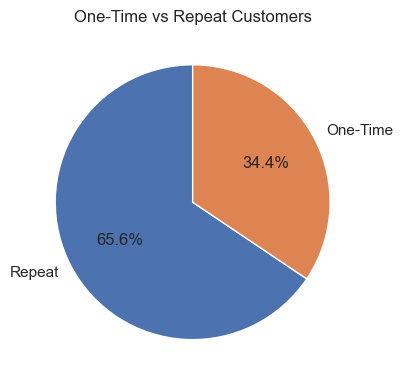

In [73]:
customer_type_counts = customer_summary["Customer_Type"].value_counts()

plt.figure(figsize=(6, 4))

plt.pie(customer_type_counts.values, labels=customer_type_counts.index,
    autopct="%1.1f%%",
    startangle=90)

plt.title("One-Time vs Repeat Customers")

plt.tight_layout()
plt.show()

In [16]:
# Compare revenue between customer types
# Are repeat customers actually more valuable?
customer_type_revenue = (
    customer_summary
    .groupby("Customer_Type")["Revenue"]
    .agg(
        Total_Revenue="sum",
        Average_Revenue="mean",
        Median_Revenue="median"
    )
)
customer_type_revenue.round(2)

,Total_Revenue,Average_Revenue,Median_Revenue
Customer_Type,,,
One-Time,613989.56,411.25,255.91
Repeat,8273219.33,2907.99,1154.47


In [17]:
# Compare AOV
customer_summary.groupby("Customer_Type")["AOV"].agg(["mean", "median"]).round(2)

,mean,median
Customer_Type,,
One-Time,411.25,255.91
Repeat,421.00,302.56


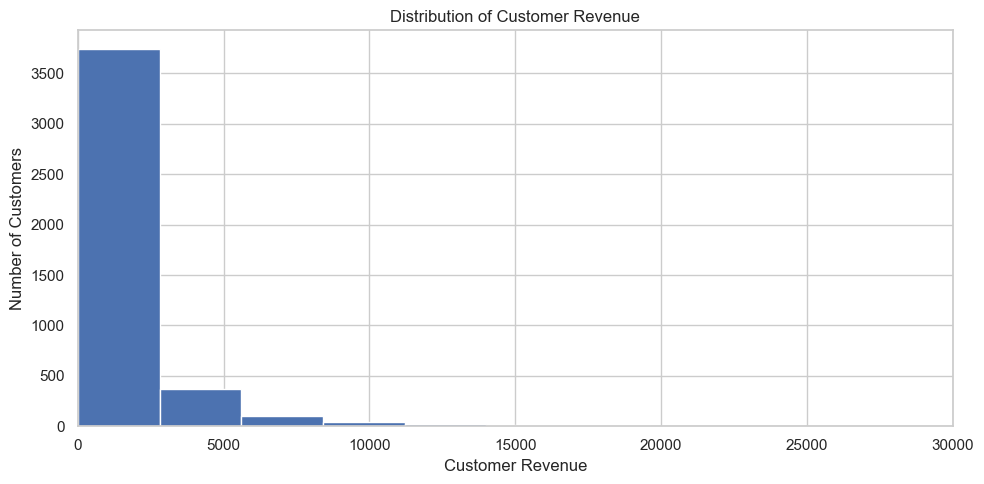

In [35]:
# Customer revenue distribution
plt.figure(figsize=(10, 5))

plt.hist(customer_summary["Revenue"],bins=100)

plt.title("Distribution of Customer Revenue")
plt.xlabel("Customer Revenue")
plt.ylabel("Number of Customers")
plt.xlim(0,30000)

plt.tight_layout()
plt.show()

97 percentile threshold: £8,150.98


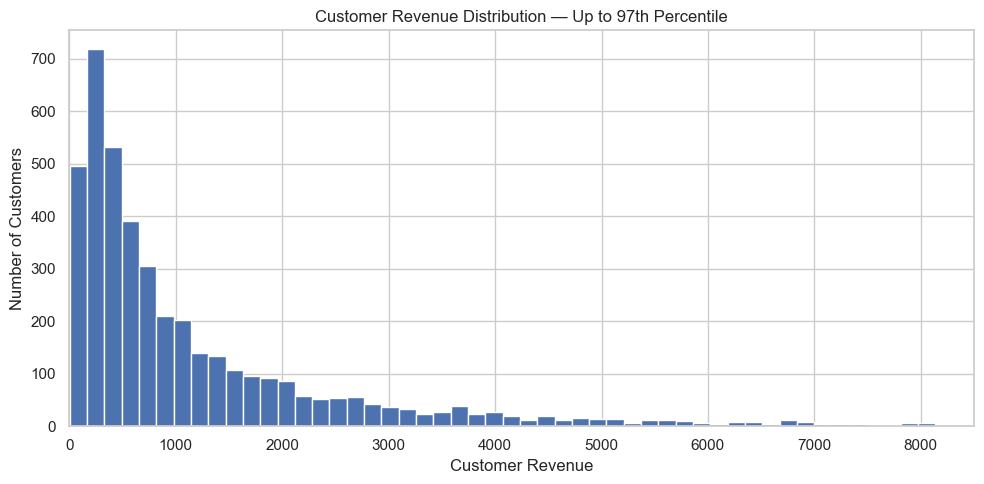

In [90]:
# Find the value below which 97% of the observations fall.
revenue_97 = customer_summary["Revenue"].quantile(0.97)
print(f"97 percentile threshold: £{revenue_97:,.2f}")

plt.figure(figsize=(10, 5))

# Find the revenue level that separates the top 3% of customers, make a histogram using the bottom 97% of customers.
plt.hist(customer_summary.loc[customer_summary["Revenue"] <= revenue_97,"Revenue"], bins=50)

plt.title("Customer Revenue Distribution — Up to 97th Percentile")
plt.xlabel("Customer Revenue")
plt.ylabel("Number of Customers")
plt.xlim(0,8500)

plt.tight_layout()
plt.show()

In [39]:
# Identify high-value customers
high_value_threshold = customer_summary["Revenue"].quantile(0.90)

high_value_customers = customer_summary[
    customer_summary["Revenue"] >= high_value_threshold
].copy()

print(f"High-value threshold: £{high_value_threshold:,.2f}")
print(f"High-value customers: {len(high_value_customers):,}")

high_value_revenue_share = (high_value_customers["Revenue"].sum() / customer_summary["Revenue"].sum())

print(f"\nRevenue contribution of top 10% customers: "
    f"{high_value_revenue_share:.2%}")

High-value threshold: £3,640.84
High-value customers: 434

Revenue contribution of top 10% customers: 61.45%


count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: Orders, dtype: float64


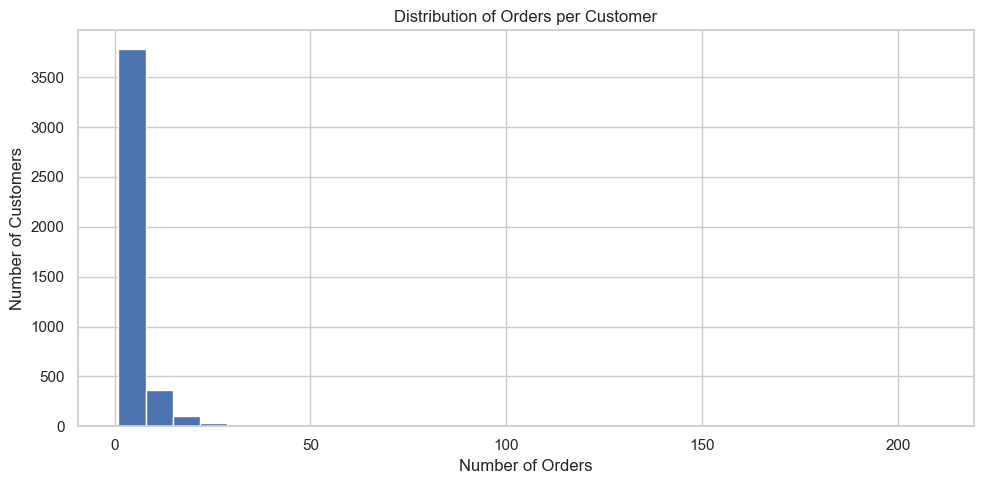

In [47]:
# Order frequency
print(customer_summary['Orders'].describe())

plt.figure(figsize=(10, 5))

plt.hist(customer_summary["Orders"], bins=30)

plt.title("Distribution of Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

count    4338.000000
mean       61.501153
std        85.366768
min         1.000000
25%        16.000000
50%        35.000000
75%        77.000000
max      1787.000000
Name: Unique_Products, dtype: float64


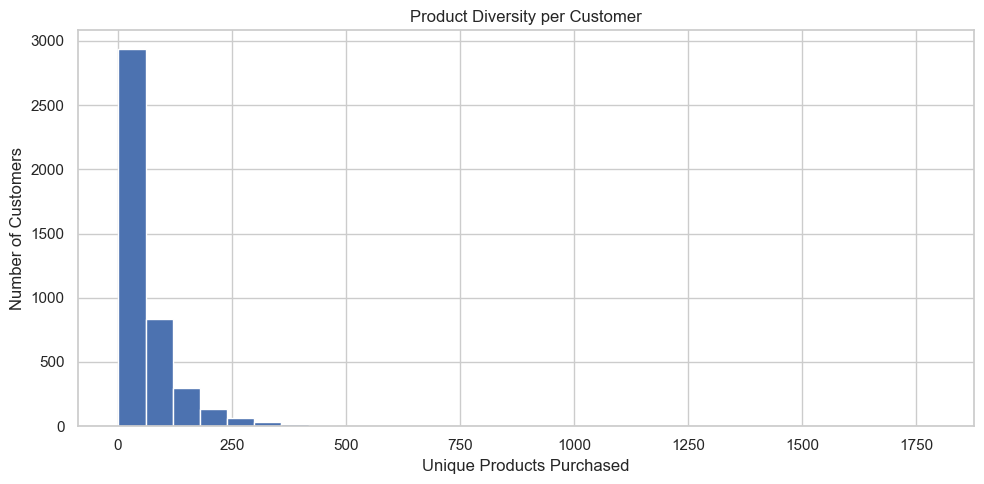

In [50]:
# Product diversity
print(customer_summary["Unique_Products"].describe())

plt.figure(figsize=(10, 5))

plt.hist(customer_summary["Unique_Products"], bins=30)

plt.title("Product Diversity per Customer")
plt.xlabel("Unique Products Purchased")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

count    4338.000000
mean      130.448594
std       132.039554
min         0.000000
25%         0.000000
50%        92.500000
75%       251.750000
max       373.000000
Name: Purchase_Span_Days, dtype: float64


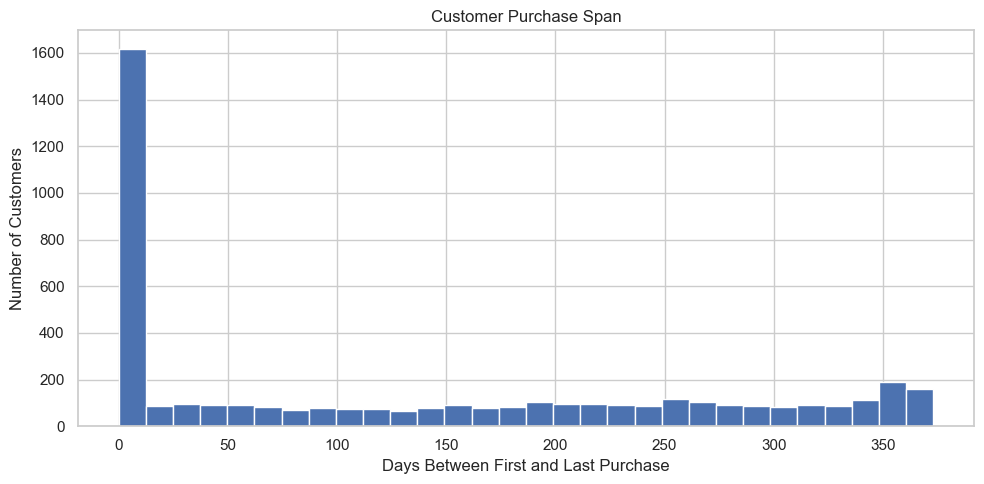

In [54]:
# Purchase span
print(customer_summary["Purchase_Span_Days"].describe())

plt.figure(figsize=(10, 5))

plt.hist(customer_summary["Purchase_Span_Days"], bins=30)

plt.title("Customer Purchase Span")
plt.xlabel("Days Between First and Last Purchase")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [55]:
# Repeat customers purchasing pattern
repeat_customers = customer_summary[customer_summary["Orders"] > 1].copy()
repeat_customers["Purchase_Span_Days"].describe()

count    2845.000000
mean      198.905448
std       113.866961
min         0.000000
25%        98.000000
50%       207.000000
75%       299.000000
max       373.000000
Name: Purchase_Span_Days, dtype: float64

In [65]:
# Order-level dataset
# Create one row per customer order
customer_orders = (
    customer_df
    .groupby(["CustomerID", "InvoiceNo"], as_index=False)
    .agg(
        Order_Date=("InvoiceDate", "min")
    )
)

customer_orders.head()

,CustomerID,InvoiceNo,Order_Date
0,12346.0,541431,2011-01-18 10:01:00
1,12347.0,537626,2010-12-07 14:57:00
2,12347.0,542237,2011-01-26 14:30:00
3,12347.0,549222,2011-04-07 10:43:00
4,12347.0,556201,2011-06-09 13:01:00


In [66]:
# Sort customer orders chronologically
customer_orders = customer_orders.sort_values(
    ["CustomerID", "Order_Date"]
).reset_index(drop=True)

customer_orders.head()

,CustomerID,InvoiceNo,Order_Date
0,12346.0,541431,2011-01-18 10:01:00
1,12347.0,537626,2010-12-07 14:57:00
2,12347.0,542237,2011-01-26 14:30:00
3,12347.0,549222,2011-04-07 10:43:00
4,12347.0,556201,2011-06-09 13:01:00


In [67]:
# Calculate the previous order date for each customer
customer_orders["Previous_Order_Date"] = (
    customer_orders
    .groupby("CustomerID")["Order_Date"]
    .shift(1)   # Move the values down by 1 row
)

# Calculate days between consecutive orders
customer_orders["Days_Between_Orders"] = (
    customer_orders["Order_Date"]
    - customer_orders["Previous_Order_Date"]
).dt.days

customer_orders.head()

,CustomerID,InvoiceNo,Order_Date,Previous_Order_Date,Days_Between_Orders
0,12346.0,541431,2011-01-18 10:01:00,NaT,NaN
1,12347.0,537626,2010-12-07 14:57:00,NaT,NaN
2,12347.0,542237,2011-01-26 14:30:00,2010-12-07 14:57:00,49.0
3,12347.0,549222,2011-04-07 10:43:00,2011-01-26 14:30:00,70.0
4,12347.0,556201,2011-06-09 13:01:00,2011-04-07 10:43:00,63.0


In [69]:
# Inter-purchase distribution
customer_orders["Days_Between_Orders"].dropna().quantile([0.25, 0.50, 0.75, 0.90, 0.95])

0.25      6.0
0.50     21.0
0.75     51.0
0.90    102.7
0.95    146.0
Name: Days_Between_Orders, dtype: float64

The typical repeat customer in this dataset purchases relatively frequently:
- 25% of intervals are 6 days or less.
- 50% are 21 days or less.
- 75% are 51 days or less.
- 90% are about 103 days or less.
- 95% are 146 days or less.

In [91]:
# Do repeat customers actually behave differently from one-time customers?
customer_summary.groupby("Customer_Type").agg(
    Customers=("Revenue", "count"),
    Total_Revenue=("Revenue", "sum"),
    Average_Revenue=("Revenue", "mean"),
    Average_Orders=("Orders", "mean"),
    Average_AOV=("AOV", "mean"),
    Average_Unique_Products=("Unique_Products", "mean")
).round(2)

,Customers,Total_Revenue,Average_Revenue,Average_Orders,Average_AOV,Average_Unique_Products
Customer_Type,,,,,,
One-Time,1493,613989.56,411.25,1.00,411.25,21.68
Repeat,2845,8273219.33,2907.99,5.99,421.00,82.40


In [92]:
# Do repeat customers buy a wider variety of products than one-time customers?
customer_summary.groupby("Customer_Type")["Unique_Products"
].agg(
    ["mean", "median", "min", "max"]
).round(2)

,mean,median,min,max
Customer_Type,,,,
One-Time,21.68,16.0,1,219
Repeat,82.40,56.0,1,1787


- Repeat customers show substantially greater product diversity than
one-time customers.
- This indicates an association between repeat purchasing and broader
product engagement. 